# 03 — VQE Completo para H₂

Ansatz: Hardware-Efficient Ansatz (HEA)  
Medição: expval direto no objeto hamiltoniano (PennyLane 0.44+)

O HEA usa camadas de rotações paramétricas + portas de emaranhamento,
sem depender da estrutura química da molécula.

In [2]:
import pennylane as qml
from pennylane import numpy as np
import numpy as np_orig
import matplotlib.pyplot as plt
from pyscf import gto, scf, fci

distancia = 0.74

#Define a molécula
mol = gto.Mole()
mol.atom   = f'H 0 0 0; H 0 0 {distancia}'
mol.basis  = 'sto-3g'
mol.unit   = 'Angstrom'
mol.verbose = 0
mol.build()

#Roda Hartree Fock para os orbitais moleculares
mf = scf.RHF(mol)
energia_hf = mf.kernel()

cisolver = fci.FCI(mf)
energia_fci, _ = cisolver.kernel()

print(f'Energia HF:  {energia_hf:.6f} Hartree')
print(f'Energia FCI: {energia_fci:.6f} Hartree')

Energia HF:  -1.116759 Hartree
Energia FCI: -1.137284 Hartree


In [3]:
geometry = np_orig.array([[0.0, 0.0, 0.0],
                           [0.0, 0.0, distancia / 0.529177]])

hamiltoniano, qubits = qml.qchem.molecular_hamiltonian(
    ['H', 'H'],
    geometry,
    basis='sto-3g',
    mapping='jordan_wigner'
)


# Verifica autovalor exato
H_matrix = qml.matrix(hamiltoniano, wire_order=range(qubits))
autovalores = np_orig.linalg.eigvalsh(H_matrix)
print(f'Menor autovalor: {autovalores[0]:.6f} Hartree')
print(f'FCI PySCF:       {energia_fci:.6f} Hartree')

Menor autovalor: -1.137284 Hartree
FCI PySCF:       -1.137284 Hartree


## Hardware-Efficient Ansatz (HEA)

O HEA é construído com camadas repetidas de:
1. Rotações RY e RZ em cada qubit (parâmetros variacionais)
2. Portas CNOT entre qubits vizinhos (emaranhamento)

Para 4 qubits com 2 camadas:
- 4 qubits × 2 rotações × 2 camadas = 16 parâmetros
- É mais expressivo que o UCCSD (3 parâmetros) mas menos estruturado

In [4]:
dev = qml.device('default.qubit', wires=qubits)
n_camadas = 2
n_params  = qubits * 2 * n_camadas  # RY + RZ por qubit por camada

def camada_hea(params, camada):
    """Uma camada do HEA: rotações + emaranhamento"""
    offset = camada * qubits * 2
    # Rotações paramétricas
    for i in range(qubits):
        qml.RY(params[offset + i],          wires=i)
        qml.RZ(params[offset + qubits + i], wires=i)
    # Emaranhamento entre qubits vizinhos
    for i in range(qubits - 1):
        qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev)
def circuito_hea(params):
    # Estado inicial: superposição uniforme
    for i in range(qubits):
        qml.Hadamard(wires=i)
    # Camadas HEA
    for c in range(n_camadas):
        camada_hea(params, c)
    return qml.expval(hamiltoniano)

# Visualiza circuito
params_teste = np.zeros(n_params)
print(qml.draw(circuito_hea)(params_teste))
print(f'\nParâmetros totais: {n_params}')
print(f'Energia inicial:   {float(circuito_hea(params_teste)):.6f} Hartree')

0: ──H──RY(0.00)──RZ(0.00)─╭●──RY(0.00)──RZ(0.00)───────────╭●──────────────┤ ╭<𝓗>
1: ──H──RY(0.00)──RZ(0.00)─╰X─╭●─────────RY(0.00)──RZ(0.00)─╰X────────╭●────┤ ├<𝓗>
2: ──H──RY(0.00)──RZ(0.00)────╰X────────╭●─────────RY(0.00)──RZ(0.00)─╰X─╭●─┤ ├<𝓗>
3: ──H──RY(0.00)──RZ(0.00)──────────────╰X─────────RY(0.00)──RZ(0.00)────╰X─┤ ╰<𝓗>

Parâmetros totais: 16
Energia inicial:   -0.097067 Hartree


In [5]:
dev = qml.device('default.qubit', wires=qubits)
n_camadas = 2
n_params  = qubits * 2 * n_camadas  # RY + RZ por qubit por camada

def camada_hea(params, camada):
    """Uma camada do HEA: rotações + emaranhamento"""
    offset = camada * qubits * 2
    # Rotações paramétricas
    for i in range(qubits):
        qml.RY(params[offset + i],          wires=i)
        qml.RZ(params[offset + qubits + i], wires=i)
    # Emaranhamento entre qubits vizinhos
    for i in range(qubits - 1):
        qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev)
def circuito_hea(params):
    # Estado inicial: superposição uniforme
    for i in range(qubits):
        qml.Hadamard(wires=i)
    # Camadas HEA
    for c in range(n_camadas):
        camada_hea(params, c)
    return qml.expval(hamiltoniano)

# Visualiza circuito
params_teste = np.zeros(n_params)
print(qml.draw(circuito_hea)(params_teste))
print(f'\nParâmetros totais: {n_params}')
print(f'Energia inicial:   {float(circuito_hea(params_teste)):.6f} Hartree')

0: ──H──RY(0.00)──RZ(0.00)─╭●──RY(0.00)──RZ(0.00)───────────╭●──────────────┤ ╭<𝓗>
1: ──H──RY(0.00)──RZ(0.00)─╰X─╭●─────────RY(0.00)──RZ(0.00)─╰X────────╭●────┤ ├<𝓗>
2: ──H──RY(0.00)──RZ(0.00)────╰X────────╭●─────────RY(0.00)──RZ(0.00)─╰X─╭●─┤ ├<𝓗>
3: ──H──RY(0.00)──RZ(0.00)──────────────╰X─────────RY(0.00)──RZ(0.00)────╰X─┤ ╰<𝓗>

Parâmetros totais: 16
Energia inicial:   -0.097067 Hartree


In [6]:
np_orig.random.seed(42)
params = np.array(
    np_orig.random.uniform(-np_orig.pi, np_orig.pi, n_params),
    requires_grad=True
)

opt      = qml.AdamOptimizer(stepsize=0.05)
historico = []

print('Iniciando otimização VQE com HEA...\n')
for i in range(200):
    params, energia = opt.step_and_cost(circuito_hea, params)
    historico.append(float(energia))
    if i % 20 == 0:
        erro = abs(float(energia) - energia_fci) * 1000
        print(f'Iteração {i:3d} | Energia: {float(energia):.6f} Ha | Erro: {erro:.4f} mHa')

erro_final = abs(historico[-1] - energia_fci) * 1000
print(f'\n{"="*55}')
print(f'Energia VQE (HEA):  {historico[-1]:.6f} Hartree')
print(f'Energia HF:         {energia_hf:.6f} Hartree')
print(f'Energia FCI:        {energia_fci:.6f} Hartree')
print(f'Erro vs FCI:        {erro_final:.4f} mHartree')
print(f'Chemical accuracy:  1.6 mHartree')
print(f'Atingiu accuracy:   {"SIM ✓" if erro_final < 1.6 else "NÃO ✗"}')

Iniciando otimização VQE com HEA...

Iteração   0 | Energia: -0.089045 Ha | Erro: 1048.2387 mHa
Iteração  20 | Energia: -0.542142 Ha | Erro: 595.1415 mHa
Iteração  40 | Energia: -0.880468 Ha | Erro: 256.8158 mHa
Iteração  60 | Energia: -1.111406 Ha | Erro: 25.8773 mHa
Iteração  80 | Energia: -1.135339 Ha | Erro: 1.9453 mHa
Iteração 100 | Energia: -1.137114 Ha | Erro: 0.1702 mHa
Iteração 120 | Energia: -1.137262 Ha | Erro: 0.0216 mHa
Iteração 140 | Energia: -1.137279 Ha | Erro: 0.0044 mHa
Iteração 160 | Energia: -1.137284 Ha | Erro: 0.0003 mHa
Iteração 180 | Energia: -1.137284 Ha | Erro: 0.0001 mHa

Energia VQE (HEA):  -1.137284 Hartree
Energia HF:         -1.116759 Hartree
Energia FCI:        -1.137284 Hartree
Erro vs FCI:        0.0000 mHartree
Chemical accuracy:  1.6 mHartree
Atingiu accuracy:   SIM ✓


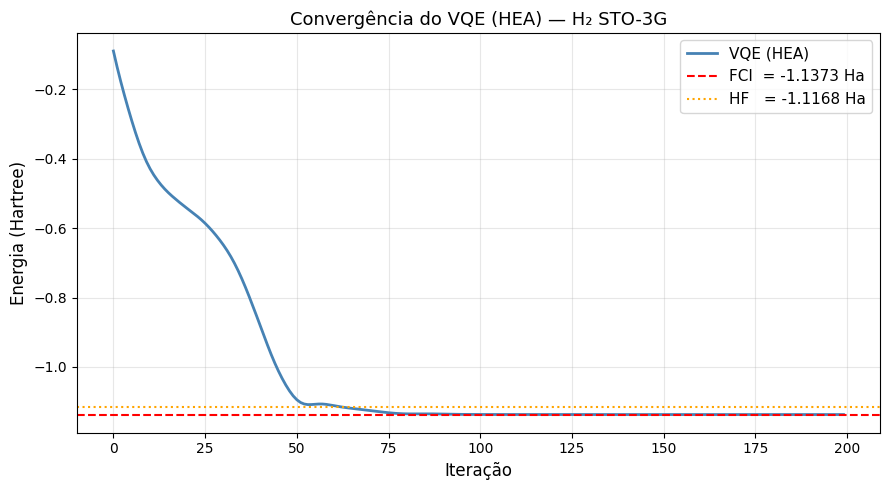

Energia de correlação total: 20.52 mHa
Recuperada pelo VQE (HEA):   20.52 mHa
Percentual:                  100.0%


In [7]:
plt.figure(figsize=(9, 5))

plt.plot(historico, color='steelblue', linewidth=2, label='VQE (HEA)')
plt.axhline(y=energia_fci, color='red',    linestyle='--',
            linewidth=1.5, label=f'FCI  = {energia_fci:.4f} Ha')
plt.axhline(y=energia_hf,  color='orange', linestyle=':',
            linewidth=1.5, label=f'HF   = {energia_hf:.4f} Ha')

plt.xlabel('Iteração', fontsize=12)
plt.ylabel('Energia (Hartree)', fontsize=12)
plt.title('Convergência do VQE (HEA) — H₂ STO-3G', fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('vqe_hea_convergencia_h2.png', dpi=150)
plt.show()

e_corr_total = abs(energia_hf - energia_fci)
e_corr_vqe   = abs(energia_hf - historico[-1])
print(f'Energia de correlação total: {e_corr_total*1000:.2f} mHa')
print(f'Recuperada pelo VQE (HEA):   {e_corr_vqe*1000:.2f} mHa')
print(f'Percentual:                  {e_corr_vqe/e_corr_total*100:.1f}%')